# Keyword analysis

In [3]:
import sys


if ".." not in sys.path:
    sys.path.append("..")

import polars as pl
import polars_corpus as plc
import polars.selectors as cs
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib.pyplot as plt

In [4]:
bnc = pl.read_parquet("bnc.parquet")
speakers = pl.read_parquet("bnc-speakers.parquet")

speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

In [5]:
table = (
    bnc.group_by((pl.col("norm") == "fox").alias("is_fuck"), "sex")
    .agg(pl.col("norm").len().alias("count"))
    .with_columns(rel_freq=pl.col("count") / pl.col("count").sum().over("sex"))
    .sort(by=["sex", "is_fuck"])
)
table

is_fuck,sex,count,rel_freq
bool,str,u32,f64
false,"""f""",2745522,0.999993
true,"""f""",20,0.000007
false,"""m""",1784710,0.999993
true,"""m""",13,0.000007


In [6]:
table = np.array(table["count"]).reshape(2, 2)
table

array([[2745522,      20],
       [1784710,      13]], dtype=uint32)

In [7]:
fisher_exact(table)

SignificanceResult(statistic=np.float64(0.9999323699648682), pvalue=1.0)

In [8]:
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), dof=1, expected_freq=array([[2.74552200e+06, 1.99994671e+01],
       [1.78471000e+06, 1.30005329e+01]]))

In [9]:
np.sqrt(chi2_contingency(table).statistic / table.sum())

np.float64(0.0)

Stefanowitsch (2020), pp. 378–380

In [48]:
freq_table = plc.crosstab(bnc, pl.col("norm").str.to_lowercase(), "sex")

In [49]:
plc.compute_loglik(freq_table).filter(
    pl.col("sex") == "m", pl.col("f12") > pl.col("f1") * (pl.col("f2") / pl.col("n"))
).sort(by="LL", descending=True)

norm,sex,f12,f1,f2,n,LL
str,str,u32,u32,u32,u32,f64
"""fucking""","""m""",1383,1709,1784723,4530265,1237.920581
"""er""","""m""",9415,18752,1784723,4530265,900.794048
"""the""","""m""",43385,100752,1784723,4530265,574.376875
""",""","""m""",84406,203556,1784723,4530265,380.46747
"""yeah""","""m""",21888,50681,1784723,4530265,305.64689
…,…,…,…,…,…,…
"""stir""","""m""",15,38,1784723,4530265,0.000097
"""pe""","""m""",15,38,1784723,4530265,0.000097
"""charges""","""m""",15,38,1784723,4530265,0.000097


In [50]:
plc.compute_loglik(freq_table).filter(
    pl.col("sex") == "f", pl.col("f12") > pl.col("f1") * (pl.col("f2") / pl.col("n"))
).sort(by="LL", descending=True)

norm,sex,f12,f1,f2,n,LL
str,str,u32,u32,u32,u32,f64
"""she""","""f""",22807,29844,2745542,4530265,3373.99179
"""her""","""f""",7306,9619,2745542,4530265,1017.03576
"""said""","""f""",12375,17286,2745542,4530265,915.450508
"""n't""","""f""",44380,68601,2745542,4530265,494.184219
"""i""","""f""",93330,148155,2745542,4530265,369.237042
…,…,…,…,…,…,…
"""saving""","""f""",40,66,2745542,4530265,7.1989e-8
"""trips""","""f""",20,33,2745542,4530265,3.5384e-8
"""jade""","""f""",20,33,2745542,4530265,3.5384e-8


In [51]:
keywords = (
    plc.compute_loglik(freq_table)
    .filter(pl.col("f12") > pl.col("f1") * (pl.col("f2") / pl.col("n")))
    .sort(by="LL", descending=True)
    .head(20)
)

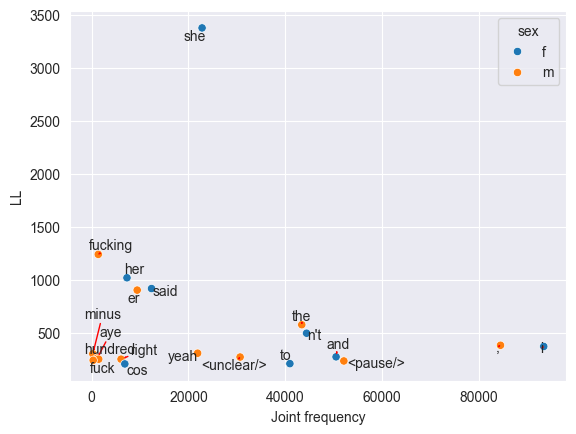

In [52]:
ax = sns.scatterplot(keywords, x="f12", y="LL", hue="sex")

labels = []
for word, f12, ll in keywords.select("norm", "f12", "LL").iter_rows():
    labels.append(ax.text(f12, ll, word, ha="center", va="center"))
adjust_text(labels, arrowprops=dict(arrowstyle="->", color="red"))

# plt.loglog()
plt.xlabel("Joint frequency")
plt.show()

Lijffijt et al. (2016)

In [5]:
bnc.columns

['token',
 'lemma',
 'pos',
 'c5',
 'sent_tag',
 'mode',
 'text_type',
 'file_id',
 'speaker_id',
 'sex',
 'ageGroup',
 'dialect',
 'soc',
 'persName',
 'occupation',
 'persNote',
 'norm']

In [7]:
# %env POLARS_VERBOSE=1

grid = (
    bnc.select("file_id", "sex")
    .unique()
    .join(bnc.select("lemma").unique(), how="cross")
)

scores = (
    bnc.group_by("file_id", "sex", "lemma")
    .agg(pl.len().alias("freq"))
    .join(grid, on=["file_id", "sex", "lemma"], how="right")
    .fill_null(0)
    .with_columns(
        (pl.col("freq") / pl.sum("freq").over(["file_id", "sex"])).alias("rel_freq")
    )
    .group_by("lemma")
    .agg(
        pl.col("rel_freq").filter(pl.col("sex") == "m").mean().alias("m"),
        pl.col("rel_freq").filter(pl.col("sex") == "f").mean().alias("f"),
        t_test=plc.welchs_t(
            pl.col("rel_freq").filter(pl.col("sex") == "m"),
            pl.col("rel_freq").filter(pl.col("sex") == "f"),
        ),
    )
    .unnest("t_test")
    .drop_nulls()
    .filter(pl.col("stat") > 0)
    .sort(by="pval", descending=False)
)

scores

lemma,m,f,stat,pval,df
str,f64,f64,f64,f64,f64
"""er""",0.006279,0.00397,4.185034,0.000042,206.691615
"""quid""",0.000325,0.000124,3.769147,0.000211,216.546004
"""which""",0.000918,0.000553,3.724912,0.000257,192.173823
"""c""",0.000325,0.00013,3.692058,0.000286,201.405
"""a""",0.01906,0.016913,3.610265,0.000369,250.270892
…,…,…,…,…,…
"""folk""",0.000011,0.000011,0.001386,0.998895,270.449675
"""rally""",0.000002,0.000002,0.000951,0.999242,244.920232
"""splendidly""",4.2970e-7,4.2917e-7,0.00087,0.999307,270.99344


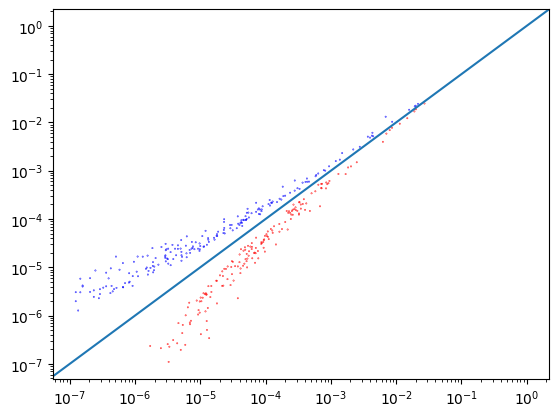

In [22]:
t = scores.filter(pl.col("pval") < 0.05).with_columns(
    color=pl.when(pl.col("m") > pl.col("f"))
    .then(pl.lit("red"))
    .otherwise(pl.lit("blue"))
)


plt.scatter(t.get_column("m"), t.get_column("f"), c=t.get_column("color"), s=0.1)
plt.loglog()
plt.axline((0, 0), (1, 1))

In [17]:
t

lemma,m,f,stat,pval,df,color
str,f64,f64,f64,f64,f64,str
"""she""",0.006919,0.013137,-6.991815,2.8466e-11,232.742791,"""blue"""
"""to""",0.015813,0.018314,-4.741965,0.000003,270.949504,"""blue"""
"""lovely""",0.000183,0.000468,-4.665211,0.000006,204.454554,"""blue"""
"""husband""",0.000023,0.000087,-3.986026,0.000102,159.934842,"""blue"""
"""child""",0.000116,0.000248,-3.8518,0.000153,223.69432,"""blue"""
…,…,…,…,…,…,…
"""shock""",0.00001,0.000022,-1.980619,0.048798,235.437345,"""blue"""
"""competition""",0.000005,0.000014,-1.981651,0.048991,186.078133,"""blue"""
"""dangle""",4.3776e-7,0.000004,-1.98431,0.049109,144.944276,"""blue"""


scattertext, word shift plots

In [ ]:
freqas